# Chapter 14 — LMM-SABR Hybrid Model

# 1. Introduction
## Stochastic Volatility, Forward-Curve Dynamics, and Interest-Rate Option Pricing

This notebook extends the Gaussian LIBOR Market Model developed in Chapter 13.

Chapter 13 used deterministic Gaussian forward-rate volatility:

$$
dL_i(t)=\mu_i(t)\,dt+\sigma_i(t)b_i\cdot dW_t.
$$

Chapter 14 replaces the deterministic diffusion scale with a displaced SABR-style stochastic-volatility structure:

$$
dL_i(t)=\mu_i(t)\,dt+g_i(t)\alpha_i(t)[L_i(t)+s_i]^{\beta_i}b_i\cdot dW_t.
$$

Each forward rate also has a stochastic volatility process:

$$
d\alpha_i(t)=\nu_i\alpha_i(t)\,dZ_i(t),
$$

with:

$$
\mathrm{Corr}(dW_i,dZ_i)=\rho_i.
$$

The notebook reuses Chapter 13 modules for market data, tenor construction, correlation, PCA, and deterministic volatility.

## Learning Objectives

After completing this notebook, the reader should understand:

- how the Chapter 13 Gaussian LMM is extended with SABR-style stochastic volatility;
- the roles of $\alpha$, $\beta$, $\rho$, $\nu$, and the displacement;
- how one stochastic-volatility process is associated with each forward rate;
- how rate and volatility shocks are correlated;
- how the terminal-measure LMM drift changes when factor loadings become stochastic;
- how forward paths and volatility paths are stored;
- how caplets and European swaptions are priced under the terminal measure;
- how strike and SABR parameters affect prices.

## Project Structure and Relative Paths

This notebook assumes:

```text
Rates-Pricing-Quant-Library/
├── 13_gaussain_libor_market_model_lmm/
│   ├── python/
│   │   ├── market_data.py
│   │   ├── tenor_structure.py
│   │   ├── correlation.py
│   │   └── volatility.py
│   └── usd_zero_curve.csv
└── 14_lmm_sabr_hybrid_model/
    ├── notebooks/
    │   └── 14_lmm_sabr_hybrid_model.ipynb
    ├── python/
    │   ├── sabr_parameters.py
    │   ├── lmm_sabr_hybrid.py
    │   ├── sabr_simulation.py
    │   ├── lmm_sabr_pricing.py
    │   ├── sabr_diagnostics.py
    │   └── lmm_sabr_plotting.py
    └── tests/
        └── test.py
```

The notebook uses the simple relative paths `../python` and `../../13_gaussain_libor_market_model_lmm/python`. Run it with the working directory set to the Chapter 14 `notebooks` folder.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CHAPTER14_PYTHON = Path("../python")
CHAPTER13 = Path("../../13_gaussain_libor_market_model_lmm")
CHAPTER13_PYTHON = CHAPTER13 / "python"

sys.path.insert(0, str(CHAPTER14_PYTHON))
sys.path.insert(1, str(CHAPTER13_PYTHON))

print("Chapter 14 Python path:", CHAPTER14_PYTHON.resolve())
print("Chapter 13 Python path:", CHAPTER13_PYTHON.resolve())

Chapter 14 Python path: C:\Users\HP16-af0022TU (D)\Desktop\Rates-Pricing-Quant-Library\14_lmm_sabr_hybrid_model\python
Chapter 13 Python path: C:\Users\HP16-af0022TU (D)\Desktop\Rates-Pricing-Quant-Library\13_gaussain_libor_market_model_lmm\python


---
# 2. Load Libraries and Data
## 2.1 Import Reused Chapter 13 Modules

The following modules are reused without duplication:

- `market_data.py`: loads and interpolates the zero curve;
- `tenor_structure.py`: creates tenor dates, accruals, forwards, and discount factors;
- `correlation.py`: builds the forward-rate correlation matrix and PCA loadings;
- `volatility.py`: supplies the deterministic maturity-dependent volatility backbone.

In [5]:
from market_data import load_curve_data
from tenor_structure import TenorStructure
from correlation import exponential_correlation_matrix, principal_component_loadings
from volatility import GaussianLMMVolatility

## 2.2 Import Chapter 14 Modules

The Chapter 14 modules use unique names so Python does not confuse them with Chapter 13 files.

In [7]:
from sabr_parameters import SABRParameters
from lmm_sabr_hybrid import LMMSABRHybrid
from sabr_simulation import build_time_grid, exact_time_index, simulate_lmm_sabr
from lmm_sabr_pricing import bond_prices_from_forwards, swap_annuity_and_rate, price_caplet_mc, price_payer_swaption_mc
from sabr_diagnostics import parameter_table, simulation_state_table, distribution_summary, last_forward_drift_check, alpha_positivity_check, forward_validity_check
from lmm_sabr_plotting import plot_forward_paths, plot_alpha_paths, plot_forward_distribution, plot_alpha_distribution, plot_mean_forward_curves, plot_mean_alpha_curves

## 2.3 Load the Initial Zero Curve

The zero curve provides $P(0,T)=e^{-z(0,T)T}$. The initial simple forward rate is:

$$
L_i(0)=\frac{1}{\delta_i}\left[\frac{P(0,T_i)}{P(0,T_{i+1})}-1\right].
$$

In [9]:
CURVE_FILE = CHAPTER13 / "data/usd_zero_curve.csv"
curve = load_curve_data(CURVE_FILE)
print("Curve file:", CURVE_FILE.resolve())
print("Curve loaded successfully.")

Curve file: C:\Users\HP16-af0022TU (D)\Desktop\Rates-Pricing-Quant-Library\13_gaussain_libor_market_model_lmm\data\usd_zero_curve.csv
Curve loaded successfully.


---
# 3. Build the Tenor Structure

We use a semiannual tenor from 0 to 10 years. Each $L_i(t)$ corresponds to $[T_i,T_{i+1}]$, with $\delta_i=0.5$.

In [10]:
tenor = TenorStructure(start=0.0, end=10.0, payment_frequency=2)
initial_forwards = tenor.initial_forward_rates(curve)
initial_discount_factors = tenor.initial_discount_factors(curve)
reset_times = np.asarray(tenor.times[:-1], dtype=float)

print("Number of tenor dates:", len(tenor.times))
print("Number of forwards:", len(initial_forwards))
print("First five forwards:", initial_forwards[:5])

Number of tenor dates: 21
Number of forwards: 20
First five forwards: [0.02111064 0.02313276 0.0251569  0.02718307 0.02667634]


---
# 4. Construct the Forward-Rate Correlation Matrix

The exponential specification is:

$$
\rho_{ij}=\exp[-\gamma|T_i-T_j|].
$$

Smaller $\gamma$ means slower correlation decay.

In [11]:
correlation_decay = 0.10
correlation_matrix = exponential_correlation_matrix(reset_times, beta=correlation_decay)
print("Correlation matrix shape:", correlation_matrix.shape)
print("Minimum correlation:", np.min(correlation_matrix))
print("Maximum correlation:", np.max(correlation_matrix))

Correlation matrix shape: (20, 20)
Minimum correlation: 0.3867410234545012
Maximum correlation: 1.0


---
# 5. Reduce the Curve to Three Rate Factors

We retain three principal components, commonly interpreted as level, slope, and curvature. If $\rho=Q\Lambda Q^\top$, then $B=Q_3\Lambda_3^{1/2}$ and $BB^\top\approx\rho$.

In [12]:
number_of_rate_factors = 3
correlation_loadings = principal_component_loadings(correlation_matrix, n_factors=number_of_rate_factors)
print("Correlation loading shape:", correlation_loadings.shape)

Correlation loading shape: (20, 3)


---
# 6. Deterministic Volatility Backbone

The Chapter 13 volatility structure is retained as:

$$
g_i(t)=g_{\text{level}}\exp[-d(T_i-t)].
$$

The stochastic variable $\alpha_i(t)$ multiplies this backbone.

In [13]:
deterministic_volatility_model = GaussianLMMVolatility(
    reset_times=reset_times,
    sigma_level=0.25,
    decay=0.05,
    floor=0.05
)
initial_backbone_volatility = deterministic_volatility_model.instantaneous_vols(0.0)
pd.DataFrame({"reset_time": reset_times, "deterministic_volatility": initial_backbone_volatility}).head(10)

,reset_time,deterministic_volatility
0,0.0,0.000000
1,0.5,0.243827
2,1.0,0.237807
3,1.5,0.231936
4,2.0,0.226209
5,2.5,0.220624
6,3.0,0.215177
7,3.5,0.209864
8,4.0,0.204683
9,4.5,0.199629


---
# 7. SABR Parameters

For each forward, the model uses:

- $\alpha_{i,0}$: initial stochastic-volatility level;
- $\beta_i\in[0,1]$: CEV elasticity;
- $\rho_i\in(-1,1)$: rate-volatility correlation;
- $\nu_i\ge0$: volatility of volatility;
- $s_i\ge0$: displacement ensuring $L_i+s_i>0$.

Interpretation:

- $\beta=0$: normal-style dynamics;
- $\beta=1$: lognormal-style dynamics;
- $0<\beta<1$: CEV-style dynamics;
- negative $\rho$: typically creates negative skew;
- larger $\nu$: typically creates stronger smile curvature.

In [14]:
sabr_parameters = SABRParameters(
    number_of_forwards=len(initial_forwards),
    alpha0=0.18,
    beta=0.50,
    rho=-0.25,
    nu=0.40,
    shift=0.03,
    alpha_floor=1.0e-8,
    alpha_cap=10.0
)
sabr_parameters.summary()

{'number_of_forwards': 20,
 'alpha0_min': 0.18,
 'alpha0_max': 0.18,
 'beta_min': 0.5,
 'beta_max': 0.5,
 'rho_min': -0.25,
 'rho_max': -0.25,
 'nu_min': 0.4,
 'nu_max': 0.4,
 'shift_min': 0.03,
 'shift_max': 0.03}

---
# 8. LMM-SABR dynamics
## 8.1 Hybrid Forward-Rate Dynamics

The hybrid loading is:

$$
\lambda_i(t)=g_i(t)\alpha_i(t)[L_i(t)+s_i]^{\beta_i}b_i.
$$

Thus the diffusion depends on time to reset, stochastic volatility, the shifted forward level, and common curve factors.

## 8.2 Stochastic-Volatility Dynamics

The model uses:

$$
d\alpha_i(t)=\nu_i\alpha_i(t)dZ_i(t).
$$

The exact lognormal step is:

$$
\alpha_i(t+\Delta t)=\alpha_i(t)\exp\left[-\frac12\nu_i^2\Delta t+\nu_i\sqrt{\Delta t}Z_i\right].
$$

The volatility shock is built as:

$$
Z_i^\alpha=\rho_iZ_i^L+\sqrt{1-\rho_i^2}Z_i^\perp.
$$

## 8.3 Terminal-Measure Drift

Using $P(t,T_N)$ as numeraire, the drift is:

$$
\mu_i(t)=-\sum_{j=i+1}^{N-1}\frac{\delta_j\lambda_i(t)\cdot\lambda_j(t)}{1+\delta_jL_j(t)}.
$$

Because the loadings are stochastic, the drift changes with both the forward curve and the stochastic-volatility state. The last forward still has zero drift.

---
# 9. Build the LMM-SABR Hybrid Model

In [15]:
model = LMMSABRHybrid(
    tenor_structure=tenor,
    initial_forwards=initial_forwards,
    deterministic_volatility_model=deterministic_volatility_model,
    correlation_loadings=correlation_loadings,
    initial_discount_factors=initial_discount_factors,
    sabr_parameters=sabr_parameters
)
model.summary()

{'model': 'LMM-SABR Hybrid',
 'number_of_forwards': 20,
 'number_of_rate_factors': 3,
 'initial_terminal_discount_factor': 0.7408182206817179,
 'sabr_parameters': {'number_of_forwards': 20,
  'alpha0_min': 0.18,
  'alpha0_max': 0.18,
  'beta_min': 0.5,
  'beta_max': 0.5,
  'rho_min': -0.25,
  'rho_max': -0.25,
  'nu_min': 0.4,
  'nu_max': 0.4,
  'shift_min': 0.03,
  'shift_max': 0.03}}

## 9.1 Inspect Parameters and Initial Loadings

The parameter table has one row per forward. The loading matrix has shape `number of forwards × number of retained rate factors`.

In [16]:
parameter_table(model).head(10)

,forward_index,reset_time,payment_time,accrual,initial_forward,alpha0,beta,rho,nu,shift
0,0,0.0,0.5,0.5,0.021111,0.18,0.5,-0.25,0.4,0.03
1,1,0.5,1.0,0.5,0.023133,0.18,0.5,-0.25,0.4,0.03
2,2,1.0,1.5,0.5,0.025157,0.18,0.5,-0.25,0.4,0.03
3,3,1.5,2.0,0.5,0.027183,0.18,0.5,-0.25,0.4,0.03
4,4,2.0,2.5,0.5,0.026676,0.18,0.5,-0.25,0.4,0.03
5,5,2.5,3.0,0.5,0.027690,0.18,0.5,-0.25,0.4,0.03
6,6,3.0,3.5,0.5,0.028704,0.18,0.5,-0.25,0.4,0.03
7,7,3.5,4.0,0.5,0.029719,0.18,0.5,-0.25,0.4,0.03
8,8,4.0,4.5,0.5,0.030734,0.18,0.5,-0.25,0.4,0.03
9,9,4.5,5.0,0.5,0.031749,0.18,0.5,-0.25,0.4,0.03


In [17]:
initial_loadings = model.factor_loadings(
    time=0.0,
    forwards=model.initial_forwards,
    alpha=model.sabr_parameters.alpha0
)
print("Initial factor-loading shape:", initial_loadings.shape)
print("First forward loading:", initial_loadings[0])

Initial factor-loading shape: (20, 3)
First forward loading: [ 0.  0. -0.]


## 9.2 Core Model Diagnostics

Key checks are:

$$
\mu_{N-1}(t)=0,
$$

$$
\alpha_i(t)>0,
$$

and:

$$
1+\delta_iL_i(t)>0.
$$

In [18]:
last_forward_drift_check(model, time=0.0)

{'last_forward_drift': -0.0, 'absolute_error': 0.0}

---
# 10. Monte Carlo Simulation

The simulator stores:

```text
forward_paths[path, time, forward]
alpha_paths[path, time, forward]
```

The slice `forward_paths[10, 40, :]` is the full forward curve on path 10 at time index 40.

In [19]:
simulation_end = 5.0
number_of_steps = 100
number_of_paths = 3000

mandatory_times = np.concatenate([
    reset_times[reset_times <= simulation_end],
    np.array([2.0, 5.0])
])

simulation = simulate_lmm_sabr(
    model=model,
    simulation_end=simulation_end,
    number_of_steps=number_of_steps,
    number_of_paths=number_of_paths,
    seed=42,
    antithetic=True,
    mandatory_times=mandatory_times
)

print("Forward path shape:", simulation.forward_paths.shape)
print("Alpha path shape:", simulation.alpha_paths.shape)

Forward path shape: (3000, 101, 20)
Alpha path shape: (3000, 101, 20)


## 10.1 Inspect One Path at One Time

At $t=2$, the model stores the complete forward and volatility state. Earlier forwards have already reset; later forwards remain stochastic.

In [20]:
simulation_state_table(model=model, simulation=simulation, path_index=0, time=2.0).head(15)

,forward_index,reset_time,forward_rate,alpha,active
0,0,0.0,0.021111,0.180000,False
1,1,0.5,0.014142,0.271040,False
2,2,1.0,0.017676,0.100452,False
3,3,1.5,0.021564,0.262206,False
4,4,2.0,0.022209,0.089272,False
5,5,2.5,0.029566,0.450336,True
6,6,3.0,0.035667,0.190346,True
7,7,3.5,0.037348,0.117497,True
8,8,4.0,0.039854,0.155802,True
9,9,4.5,0.040888,0.046229,True


## 10.2 Distribution Diagnostics

The cross-sectional distribution across paths shows forward means, dispersion, tail quantiles, and stochastic-volatility moments.

In [21]:
distribution_summary(model=model, simulation=simulation, time=2.0).head(15)

,forward_index,reset_time,forward_mean,forward_std,forward_5_percent,forward_95_percent,alpha_mean,alpha_std
0,0,0.0,0.021111,8.466862e-16,0.021111,0.021111,0.180000,3.025862e-15
1,1,0.5,0.022871,7.190654e-03,0.011360,0.034283,0.179822,5.116811e-02
2,2,1.0,0.024607,1.053759e-02,0.007047,0.041858,0.179634,7.332247e-02
3,3,1.5,0.026444,1.292662e-02,0.005074,0.047195,0.179739,9.279139e-02
4,4,2.0,0.025695,1.475267e-02,0.001259,0.049299,0.181419,1.146326e-01
5,5,2.5,0.027042,1.433887e-02,0.003753,0.049718,0.179902,1.093012e-01
6,6,3.0,0.028243,1.414050e-02,0.005373,0.051246,0.177997,1.036238e-01
7,7,3.5,0.028927,1.383318e-02,0.006146,0.050974,0.180320,1.104173e-01
8,8,4.0,0.030123,1.380614e-02,0.007196,0.053029,0.181084,1.123326e-01
9,9,4.5,0.031338,1.360338e-02,0.009262,0.053154,0.182185,1.157248e-01


In [22]:
print(alpha_positivity_check(simulation))
print(forward_validity_check(model, simulation))

{'minimum_alpha': 0.003651307918405163, 'all_positive': True}
{'minimum_denominator': 0.985000005, 'all_valid': True}


## 10.3 Plot Forward and Volatility Paths

These plots illustrate one forward rate, its stochastic volatility, and the freezing of both after reset.

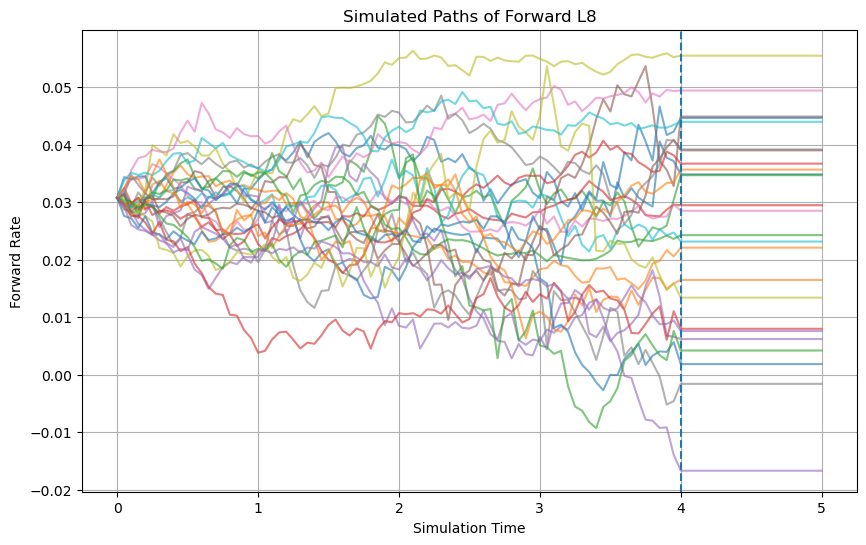

In [23]:
forward_index_to_plot = 8
plot_forward_paths(model=model, simulation=simulation, forward_index=forward_index_to_plot, number_of_paths_to_plot=25)

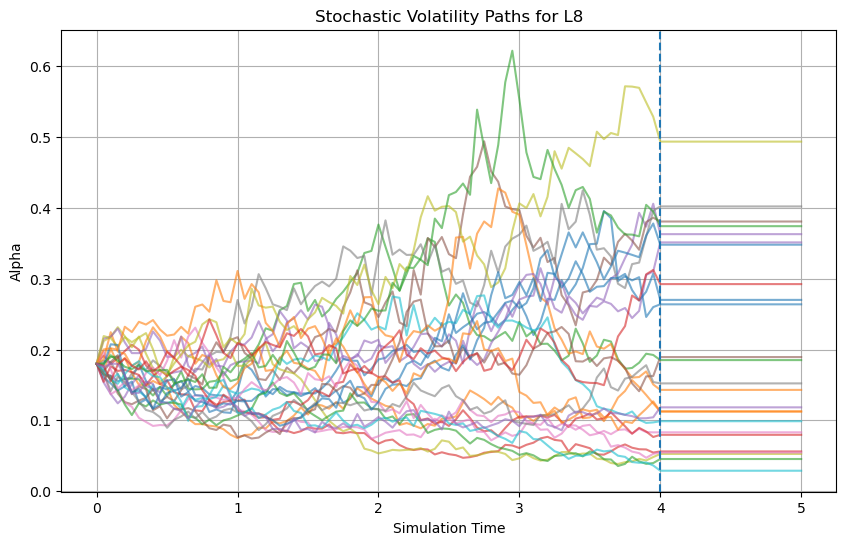

In [24]:
plot_alpha_paths(model=model, simulation=simulation, forward_index=forward_index_to_plot, number_of_paths_to_plot=25)

## 10.4 Forward and Volatility Distributions

The forward-rate distribution need not remain Gaussian because the diffusion scale depends on both $\alpha_i(t)$ and $[L_i(t)+s_i]^{\beta_i}$.

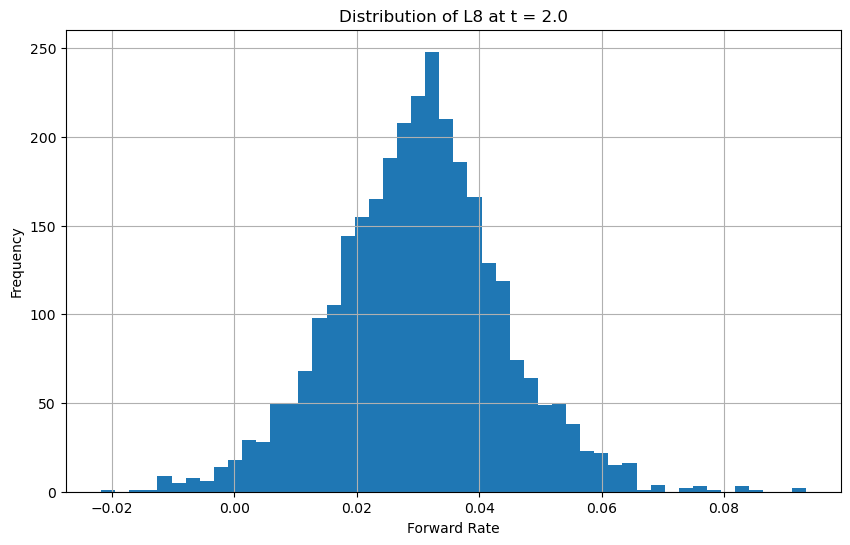

In [25]:
plot_forward_distribution(simulation=simulation, forward_index=8, time=2.0, number_of_bins=50)

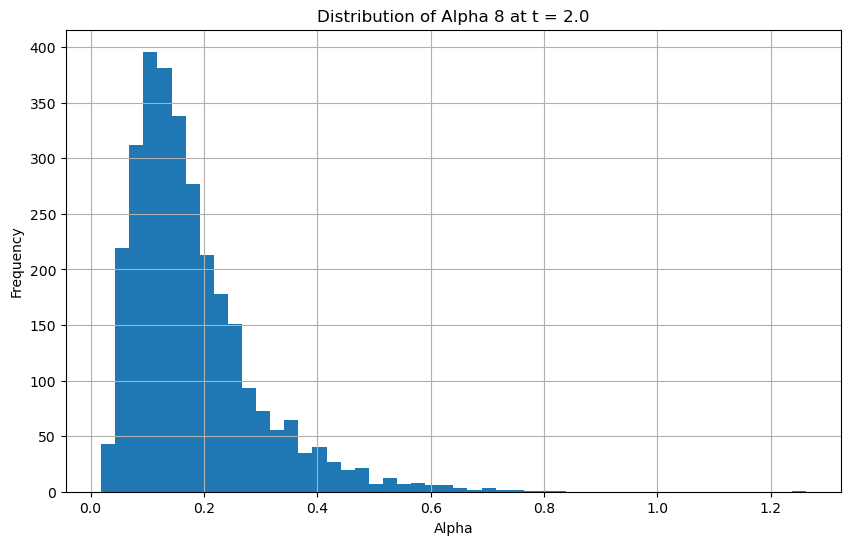

In [26]:
plot_alpha_distribution(simulation=simulation, forward_index=8, time=2.0, number_of_bins=50)

---
# 11. Pricing Examples
## 11.1 Caplet Pricing

A caplet fixing at $T_i$ and paying at $T_{i+1}$ has payment:

$$
N\delta_i\max[L_i(T_i)-K,0].
$$

Its reset-date value is:

$$
V(T_i)=\frac{N\delta_i\max[L_i(T_i)-K,0]}{1+\delta_iL_i(T_i)}.
$$

Under the terminal measure:

$$
V(0)=P(0,T_N)\,\mathbb{E}^{T_N}\left[\frac{V(T_i)}{P(T_i,T_N)}\right].
$$

In [27]:
caplet_result = price_caplet_mc(
    model=model,
    simulation=simulation,
    reset_time=2.0,
    strike=0.045,
    notional=1_000_000.0
)
caplet_result

{'price': 369.70305383892935, 'standard_error': 32.81933467460558}

## 11.2 European Payer Swaption Pricing

The payoff is:

$$
NA(T_k)\max[S(T_k)-K,0].
$$

The annuity and par rate are:

$$
A(T_k)=\sum_{j=k}^{m-1}\delta_jP(T_k,T_{j+1}),
$$

$$
S(T_k)=\frac{1-P(T_k,T_m)}{A(T_k)}.
$$

A swaption depends on a segment of the forward curve, not just one forward.

In [28]:
swaption_result = price_payer_swaption_mc(
    model=model,
    simulation=simulation,
    expiry=2.0,
    swap_end=5.0,
    strike=0.045,
    notional=1_000_000.0
)
swaption_result

{'price': 1921.1719643462118,
 'standard_error': 139.15700920087758,
 'mean_expiry_swap_rate': 0.028512428880889673,
 'mean_expiry_annuity': 2.8612555202559244}

---
# 12. Sensitivity Analysis
## 12.1 Strike Sensitivity

For payer options, a higher strike should reduce the option value. The same paths are reused across strikes to reduce Monte Carlo noise.

In [29]:
strikes = np.array([0.035, 0.040, 0.045, 0.050, 0.055])
strike_results = []

for strike in strikes:
    caplet = price_caplet_mc(model, simulation, 2.0, strike, 1_000_000.0)
    swaption = price_payer_swaption_mc(model, simulation, 2.0, 5.0, strike, 1_000_000.0)
    strike_results.append({
        "strike": strike,
        "caplet_price": caplet["price"],
        "swaption_price": swaption["price"]
    })

strike_table = pd.DataFrame(strike_results)
strike_table

,strike,caplet_price,swaption_price
0,0.035,1164.290236,7669.569531
1,0.040,663.012831,4067.377846
2,0.045,369.703054,1921.171964
3,0.050,201.091846,765.411750
4,0.055,110.247545,285.821578


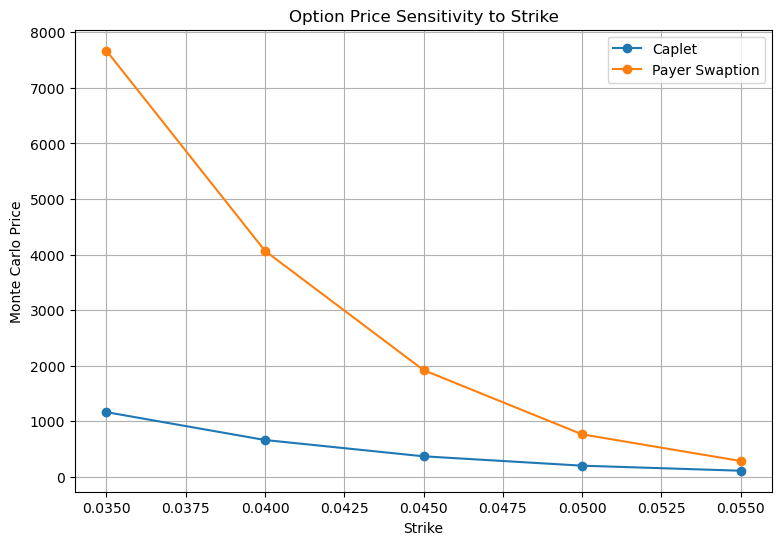

In [30]:
plt.figure(figsize=(9, 6))
plt.plot(strike_table["strike"], strike_table["caplet_price"], marker="o", label="Caplet")
plt.plot(strike_table["strike"], strike_table["swaption_price"], marker="o", label="Payer Swaption")
plt.title("Option Price Sensitivity to Strike")
plt.xlabel("Strike")
plt.ylabel("Monte Carlo Price")
plt.grid()
plt.legend()
plt.show()

## 12.2 SABR Parameter Interpretation

- $\alpha_0$ controls the initial volatility level.
- $\beta$ controls how volatility depends on the shifted forward level.
- $\rho$ controls skew direction and strength.
- $\nu$ controls volatility-of-volatility and smile curvature.

A full sensitivity run requires a new simulation for each parameter set.

In [31]:
def build_alternative_model(beta_value=0.50, rho_value=-0.25, nu_value=0.40, alpha0_value=0.18):
    alternative_sabr = SABRParameters(
        number_of_forwards=len(initial_forwards),
        alpha0=alpha0_value,
        beta=beta_value,
        rho=rho_value,
        nu=nu_value,
        shift=0.03,
        alpha_floor=1.0e-8,
        alpha_cap=10.0
    )
    return LMMSABRHybrid(
        tenor_structure=tenor,
        initial_forwards=initial_forwards,
        deterministic_volatility_model=deterministic_volatility_model,
        correlation_loadings=correlation_loadings,
        initial_discount_factors=initial_discount_factors,
        sabr_parameters=alternative_sabr
    )

## 12.3 Small Volatility-of-Volatility Sensitivity Example

This example uses fewer paths because each $\nu$ value requires a separate simulation. Treat it as a numerical illustration rather than a calibrated market conclusion.

In [32]:
nu_values = [0.0, 0.20, 0.40, 0.60]
nu_results = []

for nu_value in nu_values:
    alternative_model = build_alternative_model(nu_value=nu_value)
    alternative_simulation = simulate_lmm_sabr(
        model=alternative_model,
        simulation_end=2.0,
        number_of_steps=40,
        number_of_paths=800,
        seed=42,
        antithetic=True,
        mandatory_times=[0.5, 1.0, 1.5, 2.0]
    )
    result = price_caplet_mc(alternative_model, alternative_simulation, 2.0, 0.045, 1_000_000.0)
    nu_results.append({
        "nu": nu_value,
        "caplet_price": result["price"],
        "standard_error": result["standard_error"]
    })

pd.DataFrame(nu_results)

,nu,caplet_price,standard_error
0,0.0,364.556673,65.688226
1,0.2,337.187638,65.193505
2,0.4,352.209916,70.204167
3,0.6,434.085033,78.852281


---
# 13. Chapter Summary

The workflow is:

```text
Chapter 13 zero curve
        ↓
Initial discount factors
        ↓
Initial forward curve
        ↓
Exponential correlation
        ↓
Three PCA rate factors
        ↓
Deterministic volatility backbone
        ↓
Forward-specific SABR parameters
        ↓
Stochastic forward and alpha paths
        ↓
Terminal-measure pricing
        ↓
Caplet and swaption values
```

The key extension is:

```text
Chapter 13:
deterministic Gaussian volatility

Chapter 14:
stochastic SABR-style volatility
+
CEV elasticity
+
rate-volatility correlation
+
volatility of volatility
```

A natural extention is calibration to a caplet or swaption volatility surface, or combining these dynamics with the Chapter 12 LSM engine for Bermudan swaption pricing.

## Model Limitations and Numerical Considerations

This is an educational implementation. Important limitations include:

- no calibration to caplet or swaption volatility surfaces;
- one stochastic-volatility process per forward;
- simplified rate-volatility correlation construction;
- Euler discretization for forwards;
- deterministic PCA correlation loadings;
- no predictor-corrector drift scheme;
- no stochastic correlation;
- no Bermudan exercise;
- no automatic differentiation.

The implementation enforces $L_i(t)+s_i>0$ through a small numerical floor after the Euler step. This prevents invalid fractional powers but introduces a small boundary-truncation bias.